BATTINGEDGE V9.5 - ENSEMBLE EVALUATION

📂 Loading test data...


d:\Users\Anoshia\BattingEdge_FYP\venv\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


   Test Samples: 378
   3D Shape (LSTM): (378, 50, 107)
   2D Shape (RF/XGB): (378, 5350)

🏗️  Loading trained models...
   ✅ Loaded BiLSTM/BiGRU: battingedge_V9_5_best.keras
   ✅ Loaded XGBoost: battingedge_V9_5_xgboost_best.json
   ✅ Loaded Random Forest: battingedge_V9_5_random_forest_best.pkl

🔮 Generating probabilities...


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished


🗳️  Calculating weighted ensemble vote...
   + Adding LSTM (Weight: 0.7)
   + Adding XGBOOST (Weight: 0.1)
   + Adding RF (Weight: 0.2)

📊 ENSEMBLE RESULTS

🏆 ENSEMBLE ACCURACY: 92.06%

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Cover Drive      0.944     0.872     0.907        78
    Cut Shot      0.866     0.877     0.871        81
     Defense      0.948     0.973     0.961        75
   Pull Shot      0.984     0.887     0.933        71
  Sweep Shot      0.880     1.000     0.936        73

    accuracy                          0.921       378
   macro avg      0.924     0.922     0.922       378
weighted avg      0.923     0.921     0.920       378

🔢 CONFUSION MATRIX:
         Cove  Cut   Defe  Pull  Swee
Cover Dr   68     5     0     0     5
Cut Shot    2    71     3     1     4
Defense     0     1    73     0     1
Pull Sho    2     5     1    63     0
Sweep Sh    0     0     0     0    73

📈 PER-CLASS ACCURACY:
   Cover Drive    :  68/ 78 =

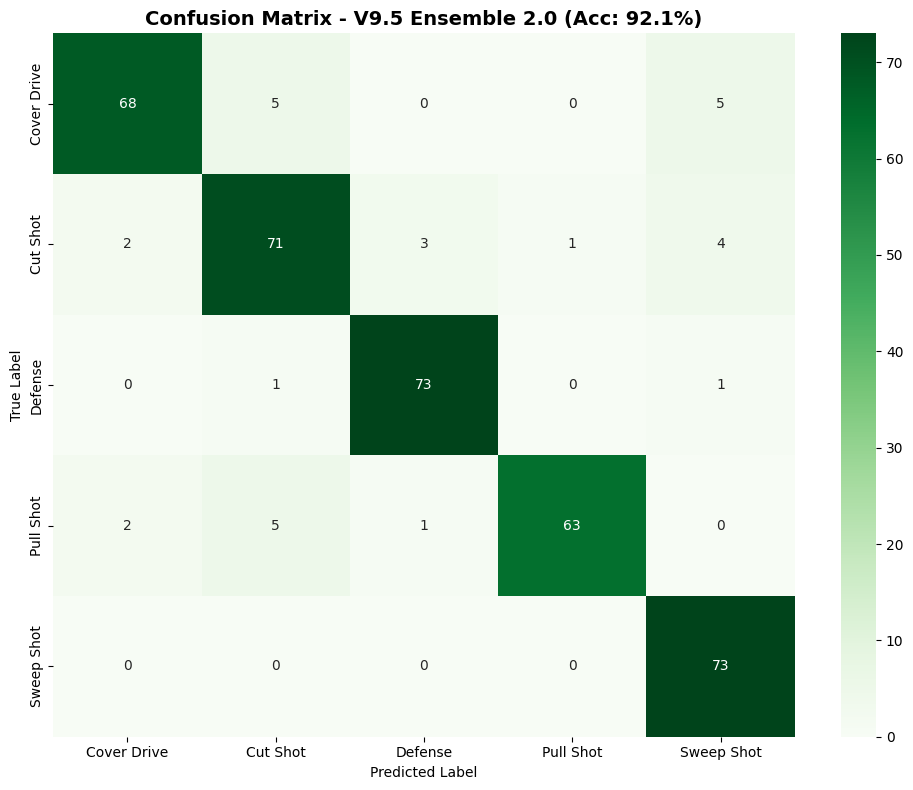

In [ ]:
# ============================================================
# BattingEdge V9.5 - ENSEMBLE MODEL (Voting Classifier)
# Combines: BiLSTM + XGBoost + Random Forest
# Target: >92% Accuracy (The "God Model")
# ============================================================

# ✅ FIX: Import Pandas first
import pandas as pd 
import numpy as np
import pickle
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import json
import joblib

# Model Imports
import tensorflow as tf
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# ================= CONFIG =================
FEATURE_DIR = Path(r"D:\Users\Anoshia\BattingEdge_FYP\features")
MODEL_DIR   = Path(r"D:\Users\Anoshia\BattingEdge_FYP\backend\models")

# Filenames of your best trained models (Verify these exist!)
MODEL_FILES = {
    "lstm": "battingedge_V9_5_best.keras",           # The 91.8% BiLSTM/BiGRU
    "xgboost": "battingedge_V9_5_xgboost_best.json", # The 87.3% XGBoost
    "rf": "battingedge_V9_5_random_forest_best.pkl"  # The 89.4% Random Forest
}

# Voting Weights (Sum to 1.0)
# Giving highest weight to BiLSTM since it was most accurate
WEIGHTS = {
    "lstm": 0.7, 
    "rf": 0.2,
    "xgboost": 0.1
}
# ==========================================

print("="*70)
print("BATTINGEDGE V9.5 - ENSEMBLE EVALUATION")
print("="*70)
print()

# ================= 1. LOAD DATA =================
print("📂 Loading test data...")

try:
    X_test_3d = np.load(FEATURE_DIR / "X_test.npy") # For LSTM (N, 50, 107)
    y_test    = np.load(FEATURE_DIR / "y_test.npy")
    
    with open(FEATURE_DIR / "classes.pkl", "rb") as f:
        CLASSES = pickle.load(f)
        
    # Scale Data (Using the LSTM scaler as standard)
    scaler = joblib.load(MODEL_DIR / "scaler_V9_5.pkl")
    N, T, F = X_test_3d.shape
    X_test_scaled_3d = scaler.transform(X_test_3d.reshape(N*T, F)).reshape(N, T, F)
    
    # Flatten for ML models (N, 5350)
    X_test_flat = X_test_scaled_3d.reshape(N, -1)
    
    print(f"   Test Samples: {N}")
    print(f"   3D Shape (LSTM): {X_test_scaled_3d.shape}")
    print(f"   2D Shape (RF/XGB): {X_test_flat.shape}")

except Exception as e:
    print(f"\n❌ Error loading data: {e}")
    exit()

print()

# ================= 2. LOAD MODELS =================
print("🏗️  Loading trained models...")

models = {}

# Load LSTM/BiGRU (Keras)
try:
    path = MODEL_DIR / MODEL_FILES["lstm"]
    models["lstm"] = tf.keras.models.load_model(str(path))
    print(f"   ✅ Loaded BiLSTM/BiGRU: {path.name}")
except:
    print(f"   ⚠️  Failed to load LSTM. Skipping.")

# Load XGBoost
try:
    path = MODEL_DIR / MODEL_FILES["xgboost"]
    xgb = XGBClassifier()
    xgb.load_model(path)
    models["xgboost"] = xgb
    print(f"   ✅ Loaded XGBoost: {path.name}")
except:
    print(f"   ⚠️  Failed to load XGBoost. Skipping.")

# Load Random Forest
try:
    path = MODEL_DIR / MODEL_FILES["rf"]
    models["rf"] = joblib.load(path)
    print(f"   ✅ Loaded Random Forest: {path.name}")
except:
    print(f"   ⚠️  Failed to load Random Forest. Skipping.")

if not models:
    print("❌ No models loaded! Exiting.")
    exit()

print()

# ================= 3. GENERATE PREDICTIONS =================
print("🔮 Generating probabilities...")

probs = {}

# LSTM Prediction (Input: 3D)
if "lstm" in models:
    p = models["lstm"].predict(X_test_scaled_3d, verbose=0)
    probs["lstm"] = p

# XGBoost Prediction (Input: 2D Flat)
if "xgboost" in models:
    p = models["xgboost"].predict_proba(X_test_flat)
    probs["xgboost"] = p

# Random Forest Prediction (Input: 2D Flat)
if "rf" in models:
    p = models["rf"].predict_proba(X_test_flat)
    probs["rf"] = p

# ================= 4. ENSEMBLE VOTING =================
print("🗳️  Calculating weighted ensemble vote...")

final_probs = np.zeros_like(list(probs.values())[0])
total_weight = 0

for name, p in probs.items():
    w = WEIGHTS.get(name, 0.0)
    if w > 0:
        print(f"   + Adding {name.upper()} (Weight: {w})")
        final_probs += (p * w)
        total_weight += w

final_probs /= total_weight
y_pred_ensemble = np.argmax(final_probs, axis=1)

print()

# ================= 5. EVALUATION =================
print("="*70)
print("📊 ENSEMBLE RESULTS")
print("="*70)
print()

# Accuracy
acc = accuracy_score(y_test, y_pred_ensemble) * 100
print(f"🏆 ENSEMBLE ACCURACY: {acc:.2f}%")
print()

# Classification Report
print("📋 CLASSIFICATION REPORT:")
report = classification_report(y_test, y_pred_ensemble, target_names=CLASSES, digits=3)
print(report)

with open(MODEL_DIR / "report_V9_5_ensemble.txt", "w") as f:
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ensemble)
print("🔢 CONFUSION MATRIX:")
print("        ", "  ".join([f"{cls[:4]:>4s}" for cls in CLASSES]))
for i, cls in enumerate(CLASSES):
    print(f"{cls[:8]:8s}", "  ".join([f"{cm[i,j]:4d}" for j in range(len(CLASSES))]))
print()

# Per-class Accuracy
print("📈 PER-CLASS ACCURACY:")
for i, cls in enumerate(CLASSES):
    correct = cm[i, i]
    total = cm[i, :].sum()
    acc_cls = (correct / total * 100) if total > 0 else 0
    print(f"   {cls:15s}: {correct:3d}/{total:3d} = {acc_cls:5.1f}%")

print()

# Visualizations
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f"Confusion Matrix - V9.5 Ensemble (Acc: {acc:.1f}%)", fontsize=14, fontweight='bold')
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig(MODEL_DIR / "confusion_matrix_V9_5_ensemble.png", dpi=300)
print("✅ Saved: confusion_matrix_V9_5_ensemble.png")

# Save Metadata
metadata = {
    "version": "V9.5 Ensemble",
    "components": list(models.keys()),
    "weights": WEIGHTS,
    "test_accuracy": acc,
    "per_class_accuracy": {
        CLASSES[i]: float((cm[i,i] / cm[i,:].sum() * 100) if cm[i,:].sum() > 0 else 0)
        for i in range(len(CLASSES))
    }
}

with open(MODEL_DIR / "metadata_V9_5_ensemble.json", "w") as f:
    json.dump(metadata, f, indent=2)

print()
print("="*70)
if acc > 92.0:
    print("🚀 SUPREME VICTORY! The Ensemble is the best model.")
elif acc > 91.8:
    print("✅ SUCCESS. Ensemble improved over single best model.")
else:
    print("⚠️ No improvement. BiLSTM alone is likely sufficient.")
print("="*70)